BMI calculator workflow
1. Height
2. Weight

input

cal BMI

output.

state
{
    height:value
    weight:value
    bmi:value
}

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
# define state
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [3]:
def calculate_bmi(state:BMIState)->BMIState:

    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)

    return state # return the state


In [4]:
def categorize_bmi(state:BMIState)->BMIState:
    bmi=state['bmi']

    match bmi:
        case bmi if bmi<18.5:
            category='Underweight'  
        case bmi if bmi<25:
            category='Normal weight'
        case bmi if bmi<30:
            category='Overweight'
        case _:
            category='Obese'            
    state['category']=category
    return state

In [5]:
# define graph
graph=StateGraph(BMIState)

# add nodes
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node("categorize_bmi",categorize_bmi) 

# add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','categorize_bmi')
graph.add_edge('categorize_bmi',END)

# compile the graph
workflow=graph.compile()

In [6]:
# execute graph
initial_state={"weight_kg":80,"height_m":1.73}
final_state=workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


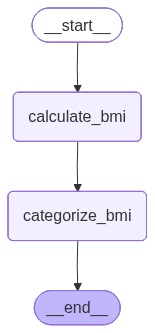

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

LLM workflow

In [8]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict

d:\FullStack_Practice\fullstack_practice\LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [9]:
llm1 = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",  # provider-backed
    task="text-generation",
    temperature=0.1,
)

llm2=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    temperature=0.2,
)

llm3=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-Coder-Next",
    task="text-generation",
    temperature=0.2,
)


LamaChat = ChatHuggingFace(llm=llm1)
QwenChat=ChatHuggingFace(llm=llm2)
QwenCoderChat=ChatHuggingFace(llm=llm3)

In [10]:
#Create a sate
class LLMState(TypedDict):
    question:str
    answer:str

In [20]:
def llm_qa(state:LLMState)->LLMState:
    #extract the question from the state
    question=state['question']
    # form the prompt 
    prompt=f'Answere the following question {question}'
    # ask that to LLM
    answer=LamaChat.invoke(prompt)
    #update the answer
    state['answer']=answer.content
    return state
    

In [21]:
graph=StateGraph(LLMState)

# add node
graph.add_node("llm_qa",llm_qa)
# add edges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

# compile the graph
workflow=graph.compile()

In [22]:
# execute the graph
initial_state={"question":"How far the moon is from teh earth?"}
final_state=workflow.invoke(initial_state)
print(final_state)

{'question': 'How far the moon is from teh earth?', 'answer': "The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the Moon is about 363,300 kilometers (225,300 miles) away, and at its farthest point (apogee), it is about 405,500 kilometers (252,000 miles) away."}


prompt chaining (Multiple LLm calls)

In [23]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict

In [26]:
class BlogState(TypedDict):
    topic:str
    outline:str
    blog:str

In [32]:
def create_outline(state:BlogState)->BlogState:
    topic=state['topic']
    prompt=f'Create a detailed outline for a blog post on the topic: {topic}'
    outline=LamaChat.invoke(prompt)
    state['outline']=outline.content
    return state

In [33]:
def create_blog(state:BlogState)->BlogState:
    outline=state['outline']
    topic=state['topic']
    prompt=f'Write a blog post based on the following outline {outline} and topic {topic}'
    blog=LamaChat.invoke(prompt)
    state['blog']=blog.content
    return state

In [34]:
graph=StateGraph(BlogState)

# add node
graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)

# add edges
graph.add_edge(START,'create_outline')  
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

# compile the graph
workflow=graph.compile()

In [36]:
# execute the graph
initial_state={"topic":"Competetion in job market after covid and AI"}
final_state=workflow.invoke(initial_state)
print(final_state)

# Write the final state to blog.txt
with open('blog.txt', 'w') as f:
    f.write(str(final_state))




{'topic': 'Competetion in job market after covid and AI', 'outline': "**Title:** Navigating the Post-Pandemic Job Market: The Impact of COVID-19 and AI on Competition\n\n**I. Introduction**\n\n* Brief overview of the COVID-19 pandemic and its effects on the job market\n* Introduction to the rise of AI and its impact on the job market\n* Thesis statement: The post-pandemic job market is becoming increasingly competitive, with the rise of AI and COVID-19 accelerating the need for workers to upskill and reskill.\n\n**II. The COVID-19 Pandemic's Impact on the Job Market**\n\n* Overview of the pandemic's effects on employment rates, industry closures, and economic downturn\n* Discussion of the shift to remote work and its impact on job requirements and skills\n* Analysis of the pandemic's impact on specific industries, such as healthcare, education, and tourism\n\n**III. The Rise of AI and Its Impact on the Job Market**\n\n* Overview of the current state of AI technology and its application